In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler
    
mne.set_log_level('ERROR')
tl.get_backend()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Obtaining dependency information for line_profiler from https://files.pythonhosted.org/packages/43/61/534f034efa3aa01cf3855a37e7d2beee8df39d85e9b1e1302dc011bedcd6/line_profiler-4.1.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.6/717.6 kB 11.8 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip


'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=46, tmin=0)
dataset = BNCI2014008()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[8],
                                         return_epochs=True)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

#epochs.pick_channels(['Cz'])

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
epochs

Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.978 s
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 46)

In [33]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.backend import lobpcg
import cupyx.scipy.sparse.linalg
import warnings

from hoda.hoda import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

hoda = HODA(
        rank=4,
        max_iter=256,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,

)
hoda.fit(X,y)
display(hoda)


  0%|          | 0/256 [00:00<?, ?it/s]

HODA(init='eye', random_state=42, rank=4, verbose=True)

  0%|          | 0/256 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,rank,objective
0,1,0,2.611979e-01,0.000280,4,0.014959
1,1,1,4.200416e-02,0.024629,4,0.005224
2,2,0,1.698494e-01,0.000272,4,0.012017
3,2,1,2.462084e-03,0.021648,4,0.004558
4,3,0,1.253681e-01,0.000280,4,0.011881
5,3,1,2.188025e-02,0.021543,4,0.004239
6,4,0,1.554977e-04,0.000281,4,0.011941
7,4,1,1.947274e-05,0.021615,4,0.004241
8,5,0,2.798834e-05,0.000281,4,0.011940
9,5,1,1.317483e-05,0.021663,4,0.004241


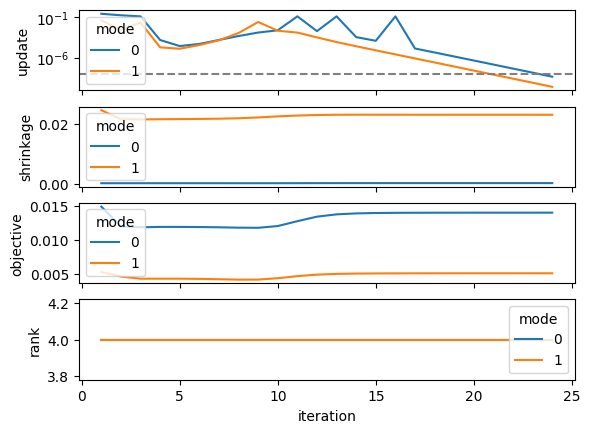

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

  0%|          | 0/256 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage
0,0,0,inf,NaN
1,0,1,inf,NaN
2,1,0,7.099135e-02,0.0
3,1,1,4.000185e-03,0.0
4,2,0,2.847617e-05,0.0
5,2,1,5.921227e-08,0.0
6,3,0,1.492591e-08,0.0
7,3,1,4.482320e-11,0.0
8,4,0,1.153376e-11,0.0
9,4,1,4.127006e-14,0.0


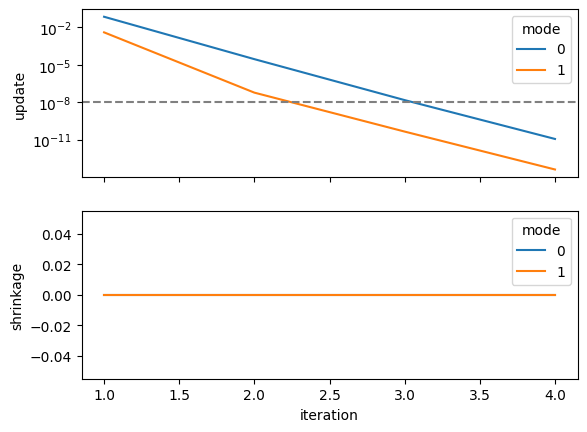

In [18]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='mse', ax=axs[0])
    axs[0].set_yscale('log')
    sns.lineplot(data=df, x=df.index, y='err_cross_corr', ax=axs[1])
    axs[1].set_yscale('log')


In [19]:
%lprun -f hoda.fit hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 0.434618 s
File: /project/src/hoda/hoda.py
Function: fit at line 141

Line #      Hits         Time  Per Hit   % Time  Line Contents
   141                                               def fit(self, X, y, classes=None, class_counts=None):
   142                                                   # Convert to tensor
   143         1      19645.0  19645.0      0.0          if not tl.is_tensor(X):
   144                                                       X = tl.tensor(X)
   145                                                   # Calculate means, centering and classes once (slow on GPU)
   146         1        281.0    281.0      0.0          if classes is None or class_counts is None:
   147         1     612928.0 612928.0      0.1              self.classes_, class_counts = np.unique(y, return_counts=True)
   148         1     290482.0 290482.0      0.1              class_counts = tl.tensor(class_counts)
   149                                           

In [20]:
from hoda.cov import ledoit_wolf_shrinkage
%lprun -f hoda.fit_backward hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 0.438667 s
File: /project/src/hoda/hoda.py
Function: fit_backward at line 166

Line #      Hits         Time  Per Hit   % Time  Line Contents
   166                                               def fit_backward(
   167                                                   self, X, y, X_centered=None, means=None, classes=None, class_counts=None
   168                                               ):
   169                                                   # TODO: calculate train info for initialization
   170                                                   # Convert to tensor
   171         1       6844.0   6844.0      0.0          if not tl.is_tensor(X):
   172                                                       X = tl.tensor(X)
   173         1       1708.0   1708.0      0.0          n_samples, *shape = X.shape
   174         1        636.0    636.0      0.0          order = len(shape)
   175                                           
   176          

In [21]:
%lprun -f hoda.fit_forward hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 0 s
File: /project/src/hoda/hoda.py
Function: fit_forward at line 340

Line #      Hits         Time  Per Hit   % Time  Line Contents
   340                                               def fit_forward(self, X, y, X_centered=None, Xt=None, Xt_centered=None):
   341                                                   # TODO: add regularization
   342                                                   # Convert to tensor
   343                                                   if not tl.is_tensor(X):
   344                                                       X = tl.tensor(X)
   345                                                   n_samples, *shape = X.shape
   346                                                   order = len(shape)
   347                                           
   348                                                   # Project
   349                                           
   350                                                   if

In [22]:
import math
from hoda.util import center

X = tl.tensor(X)
G = hoda.transform(X)
X_approx = hoda.inv_transform(G)
err = X-X_approx


<Axes: >

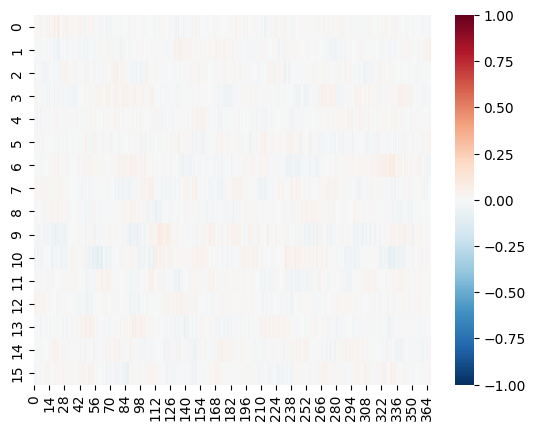

In [23]:
n_samples = X.shape[0]
G_flat = tl.to_numpy(G.reshape((n_samples, -1), order='F'), )
err_flat = tl.to_numpy(err.reshape((n_samples, -1), order='F'))
cross_corr = np.corrcoef(G_flat, err_flat, rowvar=False)
cross_corr = cross_corr[G_flat.shape[-1]:,:G_flat.shape[-1]].T
sns.heatmap(cross_corr,  cmap='RdBu_r', center=0, vmin=-1, vmax=1)

<Axes: >

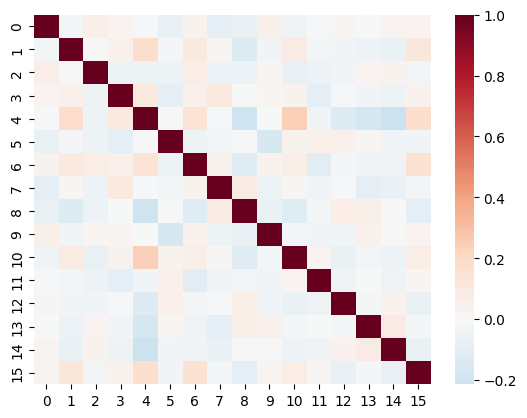

In [32]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
G_flat = tl.to_numpy(G.reshape(n_samples, -1))
sns.heatmap(np.corrcoef(G_flat, rowvar=False),  cmap='RdBu_r', center=0)

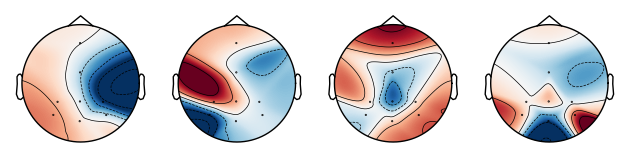

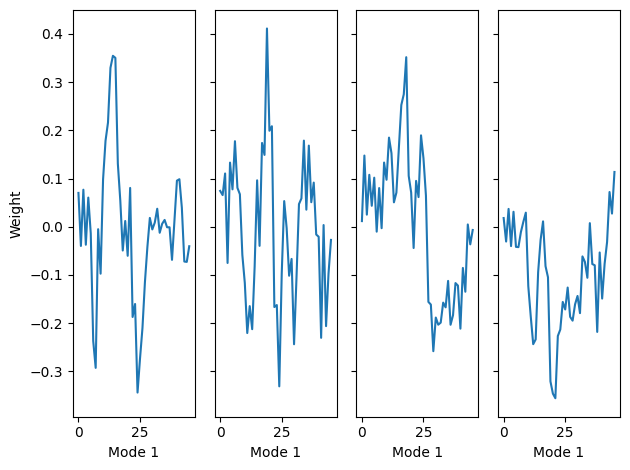

In [25]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');


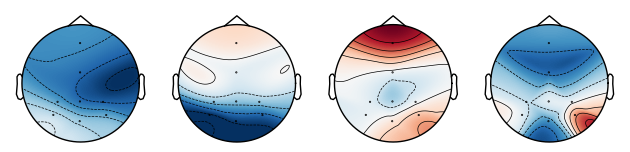

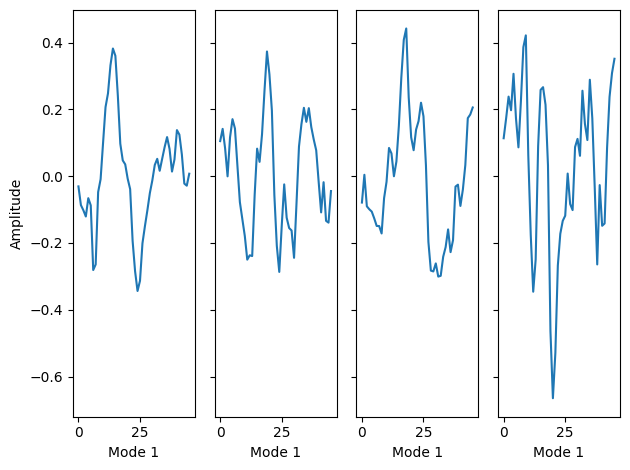

In [26]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

In [27]:
Xt = hoda.transform(X)

[[7.00149853e-04 7.78282153e-97 7.75428553e-02 4.07393889e-20]
 [0.00000000e+00 5.52651202e-09 3.19624057e-90 6.87789480e-01]
 [4.25054325e-76 2.67341366e-02 2.00952655e-40 4.96888200e-01]
 [6.47691083e-41 5.75715682e-15 4.58535340e-47 3.92109723e-72]]


<BarContainer object of 4 artists>

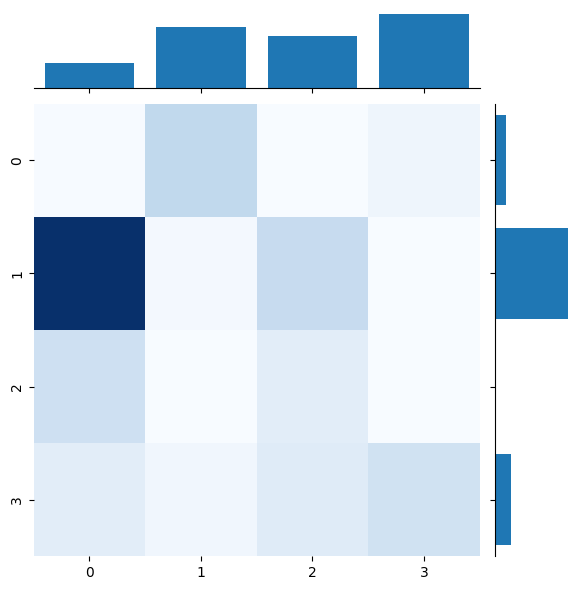

In [28]:
from hoda.util import f_multiway, f_oneway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)
print(p)
g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint,
            #mask=p>0.5/p.size,
            cbar=False,
            cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



<Axes: >

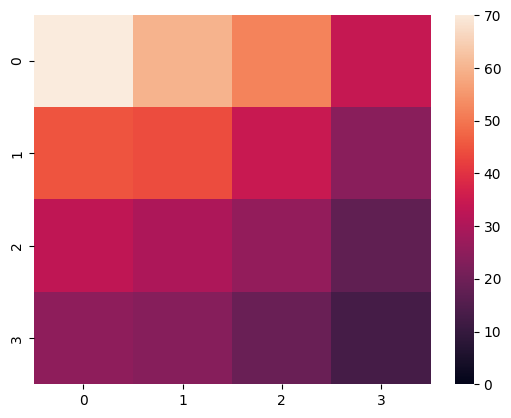

In [29]:
_,Xt_centered = center(Xt, y)
norm = tl.norm(Xt_centered, axis=0)
sns.heatmap(tl.to_numpy(norm), vmin=0)

In [34]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(4200, 16)

      index       PC1       PC2      label
0         0 -0.011439 -0.959858  NonTarget
1         1  1.716238  0.230481  NonTarget
2         2 -2.502710  1.077058  NonTarget
3         3  0.554547 -0.460872  NonTarget
4         4 -0.068319 -0.555698  NonTarget
...     ...       ...       ...        ...
4195   4195 -1.309858 -0.117476  NonTarget
4196   4196  1.772932 -0.752775     Target
4197   4197 -0.960879  1.351305  NonTarget
4198   4198  0.036626 -0.476911  NonTarget
4199   4199  0.473379 -1.148513  NonTarget

[4200 rows x 4 columns]


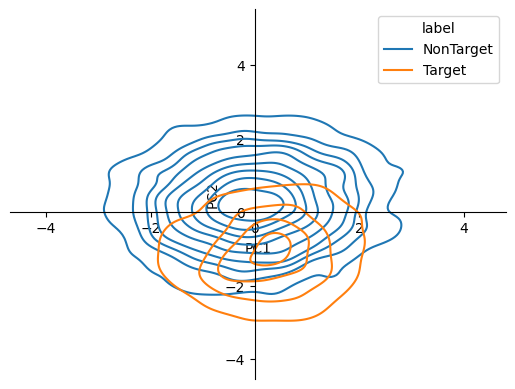

In [36]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


In [ ]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.apply_baseline((None,0)).plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [ ]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.apply_baseline((None,0)).plot_joint(title=cls,
                              **joint_args
                             )
    else:
        evoked_rec.plot(**ts_args)

In [ ]:
from mne import combine_evoked, EvokedArray

contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(
    **joint_args
)


means_rec = hoda.inv_transform(hoda.transform(hoda.means_))
contrast_rec = means_rec[1]-means_rec[0]
contrast_rec = EvokedArray(tl.to_numpy(contrast_rec), epochs.info, epochs.tmin)
_ = contrast_rec.apply_baseline((None,0)).plot_joint(
    **joint_args
)

In [ ]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.apply_baseline((None,0)).plot_joint(
    **joint_args
)